## Plotting estimated/actual super-/sub-community assignments 

This notebook defines a plotting function for estimated or actual super-/sub-community assignments.  It utilizes the 
class HierarchicalCommunityStructure from ari_test.py, as a unified interface for exxtracting community assignments 
(and coloring - I had no other obvious place to put this).   


In [1]:
# imports 
# load adjacency matrices 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle 
from typing import Optional, Tuple
from ari_test import HierarchicalCommunityStructure
import numpy as np
from matplotlib.patches import Wedge
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Wedge
import seaborn as sns
import os



In [2]:
# file names and locations
am_pickle_name, result_pickle_name, dashboard_name = "output/am_bikes.pkl", "output/bike_results.pkl", "output/bike_dashboard"


In [3]:
# load the results from the pickle file 
adjacency_matrices = pickle.load(open(am_pickle_name, "rb"))

results = pickle.load(open(result_pickle_name, "rb"))

# Create hierarchical structure for easier plotting
hcs = HierarchicalCommunityStructure.from_results(results)


In [4]:
# plotting functions for dashboard from hierarchical data 

def create_hierarchical_sunburst(
        ax: plt.Axes, 
        hcs: HierarchicalCommunityStructure, 
        t: int,
        inner_radius: float, 
        outer_radius: float, 
        font_sizes: dict,
        ) -> plt.Axes:
    """
    Create a sunburst chart showing hierarchical community structure.
    This code is loosely inspired by the code found in 
    https://github.com/klieret/sunburst/blob/master/sunburst/plot.py 

    Parameters:
    -----------
    ax : Axis to plot on
    hcs : our hierarchical community object 
    t : which time point to use for sunburst chart 
    inner_radius : radius of inner ring (super-communities)
    outer_radius : Radius of outer ring (sub-communities)
    font_sizes : Dictionary 'inner', 'outer_normal', 'outer_small'
    
    Returns:
    --------
    ax: Axis now with sunburst chart
    """
    from matplotlib.patches import Wedge
    import numpy as np
    
    # Make hierarchy count 
    hierarchy = {}
    n_nodes = hcs.n_nodes
    
    for i in range(n_nodes):
        sc = hcs.super_communities[i]
        sub = hcs.sub_communities[t, i]
        
        if sc not in hierarchy:
            hierarchy[sc] = {}
        if sub not in hierarchy[sc]:
            hierarchy[sc][sub] = 0
        hierarchy[sc][sub] += 1
        
    ring_width = outer_radius - inner_radius
    start_angle = 0
    
    # Draw sunburst
    for sc, sub_comms in sorted(hierarchy.items()):
        sg_size = sum(sub_comms.values())
        sg_angle = 360 * sg_size / n_nodes
        
        # Draw super-community wedge (inner ring)
        base_color = hcs.base_colors[sc]
        wedge = Wedge(
            (0, 0), 
            inner_radius, 
            start_angle, 
            start_angle + sg_angle,
            facecolor=base_color, 
            edgecolor='white', 
            linewidth=2)
        ax.add_patch(wedge)
        
        # Place Label for super-community
        mid_angle = np.radians(start_angle + sg_angle/2)
        label_r = inner_radius / 2  # Center of inner ring
        
        ax.text(
            label_r * np.cos(mid_angle), label_r * np.sin(mid_angle),
            f'SC{sc}\n{sg_size}', 
            ha='center', va='center', 
            fontsize=font_sizes['inner'], 
            fontweight='bold', color='white'
        )
        
        # Draw sub-communities (outer ring)
        sub_start = start_angle
        for sub, count in sorted(sub_comms.items()):
            comm_angle = 360 * count / n_nodes
            
            sub_color = hcs.sub_colors.get((sc, sub), (0.8, 0.8, 0.8))
            
            wedge = Wedge(
                (0, 0), 
                outer_radius, 
                sub_start, 
                sub_start + comm_angle,
                width=ring_width, 
                facecolor=sub_color, 
                edgecolor='white', linewidth=1
            )
            ax.add_patch(wedge)
            
            # Add label if segment is large enough
            if count > n_nodes * 0.015:
                mid_angle = np.radians(sub_start + comm_angle/2)
                label_r = (inner_radius + outer_radius) / 2  # Center of outer ring
                
                ax.text(
                    label_r * np.cos(mid_angle), label_r * np.sin(mid_angle),
                    f'{count}', 
                    ha='center', va='center', 
                    fontsize=font_sizes['outer_normal'], 
                    fontweight='normal', color='white'
                )
            
            sub_start += comm_angle
        
        start_angle += sg_angle
    
    # Set axis properties
    ax.set_xlim(-outer_radius, outer_radius)
    ax.set_ylim(-outer_radius, outer_radius)
    ax.set_aspect('equal')
    ax.axis('off')
    
    return ax


def plot_community_statistics_dashboard(hcs, adjacency_matrices, base_font_size=10, file_name=None) -> plt.Figure:
    """
    Comprehensive dashboard showing various community statistics with hierarchical colors.  

    Parameters:  
        hcs: HierarchicalCommunityStructure, our ground truth or estimated assignments in a convenience wrapper 
        adjacency_matrices: list of adjacency matrices, one for each time point 
        base_font_size: int, optional scaling for overall font sizes 
        file_name: str, optional, where to save the printout  
    
    Output:  
        fig: A chart with several subplots:  
            Community sizes at t=0  
            Evolution ov sub community sizes over time 
            Edge density matrix on super-community level 
            Normalized edge densities over time per rleationship level 
            Transition rates over time 
            Transition rates per super-community 

    A more detailed description is given in the thesis pdf.   
    """
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import seaborn as sns
    import numpy as np
    
    # Define font size categories - this makes for easy scaling of font sizes
    font_vs = 0.7 * base_font_size  
    font_s = 0.8 * base_font_size  
    font_n = base_font_size  
    font_l = 1.2 * base_font_size  
    
    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[1.2, 1, 1], width_ratios=[1, 2, 0])
    
    T = hcs.n_timepoints
    n = hcs.n_nodes
    
    # 1. Sunburst chart for hierarchical community distribution, Top LEft 
    ax1 = fig.add_subplot(gs[0, 0])
    
    font_sizes = {
        'inner': font_n,
        'outer_normal': font_n,
        'outer_small': font_s
    }
    
    create_hierarchical_sunburst(
        ax1, hcs, t=0,
        inner_radius=1.0, 
        outer_radius=1.5,
        font_sizes=font_sizes
    )
    
    ax1.set_title('Hierarchical Community Distribution', fontsize=font_l, pad=10)
    
    # 2. Community sizes over time, Top Right 
    ax2 = fig.add_subplot(gs[0, 1:])
    
    # Track sizes for each (sc, sub) combination
    comm_sizes = {}
    lines = []  
    labels = []  
    
    for t in range(T):
        size_at_t = {}
        for i in range(n):
            label = hcs.get_hierarchical_label(i, t)
            if label not in size_at_t:
                size_at_t[label] = 0
            size_at_t[label] += 1
        
        for label, size in size_at_t.items():
            if label not in comm_sizes:
                comm_sizes[label] = []
            comm_sizes[label].append(size)
    
    # Plot with hierarchical colors.  We also need to fill the legend 
    for (sc, sub), sizes in comm_sizes.items():
        color = hcs.sub_colors.get((sc, sub), (0.8, 0.8, 0.8))
        label = f'{sc}.{sub}'
        line, = ax2.plot(
            range(len(sizes)), 
            sizes, 
            label=label, 
            marker='o', color=color, 
            linewidth=2, markersize=4
        )
        lines.append(line)
        labels.append(label)
    
    # Increase y limit a bit so we can fit in the legend 
    ax2.set_ylim(
        ax2.get_ylim()[0], 
        ax2.get_ylim()[1] * 1.1
    )

    ax2.set_xlabel('Time', fontsize=font_n)
    ax2.set_ylabel('Community Size', fontsize=font_n)
    ax2.set_title('Community Sizes Over Time', fontsize=font_l)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='both', labelsize=font_s)
    
    # Sort legend entries alphabetically.  I know, but it works.  
    sorted_pairs = sorted(zip(labels, lines))
    sorted_labels, sorted_lines = zip(*sorted_pairs) 
    
    ax2.legend(
        sorted_lines, sorted_labels, 
        loc='upper center',
        ncol=len(sorted_labels), 
        fontsize=font_vs, 
        frameon=True
    )
    
    # 3. Time-aggregated edge density matrix, Middle Left 
    ax3 = fig.add_subplot(gs[1, 0])
    
    n_super = hcs.n_super 

    # Calculate average edge densities between super-communities
    edge_density_matrix = np.zeros((n_super, n_super))
    edge_count_matrix = np.zeros((n_super, n_super))
    possible_count_matrix = np.zeros((n_super, n_super))
    
    for t in range(T):
        A_t = adjacency_matrices[t]
        
        # Count edges and possible edges between each pair of super-communities
        # I did not have the time to write shorter code for this, regretfully.  
        for i in range(n):
            for j in range(i+1, n):
                sc_i = hcs.super_communities[i]
                sc_j = hcs.super_communities[j]
                
                # Possible edges
                possible_count_matrix[sc_i, sc_j] += 1
                if sc_i != sc_j: # symmetry off-diagonal 
                    possible_count_matrix[sc_j, sc_i] += 1  
                
                # Actual edges
                if A_t[i, j] > 0:
                    edge_count_matrix[sc_i, sc_j] += 1
                    if sc_i != sc_j:
                        edge_count_matrix[sc_j, sc_i] += 1
    
    # Normalize 
    for i in range(hcs.n_super):
        for j in range(hcs.n_super):
            if possible_count_matrix[i, j] > 0:
                edge_density_matrix[i, j] = edge_count_matrix[i, j] / possible_count_matrix[i, j]
    
    # Plot as heatmap with blue to orange color map but stopping early so we only use blue 
    im = ax3.imshow(edge_density_matrix, cmap='Blues', aspect='auto', vmin=0, vmax=0.3)
    
    ax3.set_xticks(range(hcs.n_super))
    ax3.set_yticks(range(hcs.n_super))
    ax3.set_xticklabels([f'SC{i}' for i in range(hcs.n_super)], fontsize=font_s)
    ax3.set_yticklabels([f'SC{i}' for i in range(hcs.n_super)], fontsize=font_s)
    
    # Actual numbers as annotations
    for i in range(hcs.n_super):
        for j in range(hcs.n_super):
            ax3.text(
                j, i, 
                f'{edge_density_matrix[i, j]:.3f}',
                ha="center", va="center", 
                color="black" if edge_density_matrix[i, j] < 0.5 else "white",
                fontsize=font_s
            )
    
    ax3.set_title('SC Edge Density Matrix', fontsize=font_l)
    
    # 4. normalized edge densities over time, Middle Right
    ax4 = fig.add_subplot(gs[1, 1:])
    
    # ctual edge counts
    within_edges_sc = []
    within_edges_sub = []
    between_edges = []

    # possible edge counts 
    possible_within_sc = []
    possible_within_sub = []
    possible_between = []

    densities_sub = []
    densities_sc = []
    densities_between = []

    # loop through t and increase counters for layered relationships.  
    # This can definitely made easier, but this was simple and works.  
    for t in range(T):
        A_t = adjacency_matrices[t]
        
        within_sc = within_sub = between = 0
        poss_within_sc = poss_within_sub = poss_between = 0
        

        for i in range(n):
            for j in range(i+1, n):
                sc_i, sub_i = hcs.get_hierarchical_label(i, t)
                sc_j, sub_j = hcs.get_hierarchical_label(j, t)
                
                if sc_i == sc_j:
                    if sub_i == sub_j:
                        poss_within_sub += 1
                    else:
                        poss_within_sc += 1
                else:
                    poss_between += 1

                
                if A_t[i, j] > 0:
                    
                    if sc_i == sc_j:
                        if sub_i == sub_j:
                            within_sub += 1
                        else:
                            within_sc += 1
                    else:
                        between += 1
        
        within_edges_sub.append(within_sub)
        within_edges_sc.append(within_sc)
        between_edges.append(between)

        possible_within_sc.append(poss_within_sc)
        possible_within_sub.append(poss_within_sub)
        possible_between.append(poss_between)

        densities_sub.append(within_sub / poss_within_sub)
        densities_sc.append(within_sc / poss_within_sc)
        densities_between.append(between / poss_between)
        
    # Plot normalized densities
    x = np.arange(T)
    ax4.plot(x, densities_sub, 'o-', label='Within Sub-Comm', color='darkgreen', linewidth=2, markersize=6)
    ax4.plot(x, densities_sc, 's-', label='Within Super-Comm', color='lightgreen', linewidth=2, markersize=6)
    ax4.plot(x, densities_between, '^-', label='Between Super-Comm', color='lightcoral', linewidth=2, markersize=6)
    
    # Add labels and title 
    ax4.set_xticks(x[::7])
    ax4.set_xticklabels([f'{d}' for d in x[::7]], fontsize=font_s)

    ax4.set_xlabel('Time (days)', fontsize=font_n)
    ax4.set_ylabel('Edge Density', fontsize=font_n)
    ax4.set_title('Hierarchical Edge Densities Over Time', fontsize=font_l)
    ax4.legend(loc='upper right', fontsize=font_s)
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(0, None)
    ax4.tick_params(axis='y', labelsize=font_s)
    

    # Count transitions for 5&6 
    h_labels = np.array([[hcs.get_hierarchical_label(i, t)[1] for t in range(T)] for i in range(n)])

    transitions = h_labels[:, 1:] != h_labels[:, :-1]
    transition_rates_time = transitions.sum(axis=0) / n
    transition_rates_node = transitions.sum(axis=1) / T

    # make a dict per supergroup
    transition_rates_per_supergroup = {}
    for sc in range(hcs.n_super):
        transition_rates_per_supergroup[sc] = transition_rates_node[hcs.super_communities == sc]

    # 5. Transition rates - Bottom Right 
    ax5 = fig.add_subplot(gs[2, 1:])
    ax5.plot(range(1, T), transition_rates_time, 'o-', color='darkblue', linewidth=2, markersize=6)

    if T <= 31:
        ax5.set_xticks(x[::7])
        ax5.set_xticklabels([f'{d}' for d in x[::7]], fontsize=font_s)
    else:
        tick_interval = 7 if T <= 90 else 30
        ax5.set_xticks(x[::tick_interval])
        ax5.set_xticklabels([f'{d}' for d in x[::tick_interval]], fontsize=font_s)
    
    ax5.set_xlabel('Time (days)', fontsize=font_n)
    ax5.set_ylabel('Transition Rate', fontsize=font_n)
    ax5.set_title('Sub-Community Transition Rate', fontsize=font_l)
    ax5.grid(True, alpha=0.3)
    ax5.set_xlim(0, T-1)
    ax5.tick_params(axis='y', labelsize=font_s)
    
    # 6. Transition rates per supergroup - Bottom LEft 
    ax6 = fig.add_subplot(gs[2, 0])
    
    # data for box plots
    box_data = [transition_rates_per_supergroup[sc] for sc in range(hcs.n_super)]
    
    box_plot = ax6.boxplot(
        box_data, 
        positions=range(n_super), 
        widths=0.6, patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        boxprops=dict(linewidth=1.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5)
    )
    
    # Color each box according to its super-community.  
    # I really could not figure out how to do this properly, so we wedge it in this way.  
    for patch, sc in zip(box_plot['boxes'], range(n_super)):
        patch.set_facecolor(hcs.base_colors[sc])
        patch.set_alpha(0.8)
    
    ax6.set_xticks(range(n_super))
    ax6.set_xticklabels([f'SC{i}' for i in range(n_super)], fontsize=font_s)
    
    ax6.set_xlabel('Super-Community', fontsize=font_n)
    ax6.set_ylabel('Transition Rate', fontsize=font_n)
    ax6.set_title('Transition Rate Distribution', fontsize=font_l)
    ax6.tick_params(axis='y', labelsize=font_s)
    ax6.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    
    # Save figure if file_name is provided
    if file_name is not None:
        
        # Save the figure
        output_path = f'{file_name}.pdf'
        fig.savefig(output_path, dpi=600, bbox_inches='tight')
        print(f"Dashboard saved to: {output_path}")
    
    return fig


Dashboard saved to: output/bike_dashboard.pdf


C:\Users\jcreu\AppData\Local\Temp\ipykernel_22092\2350599296.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


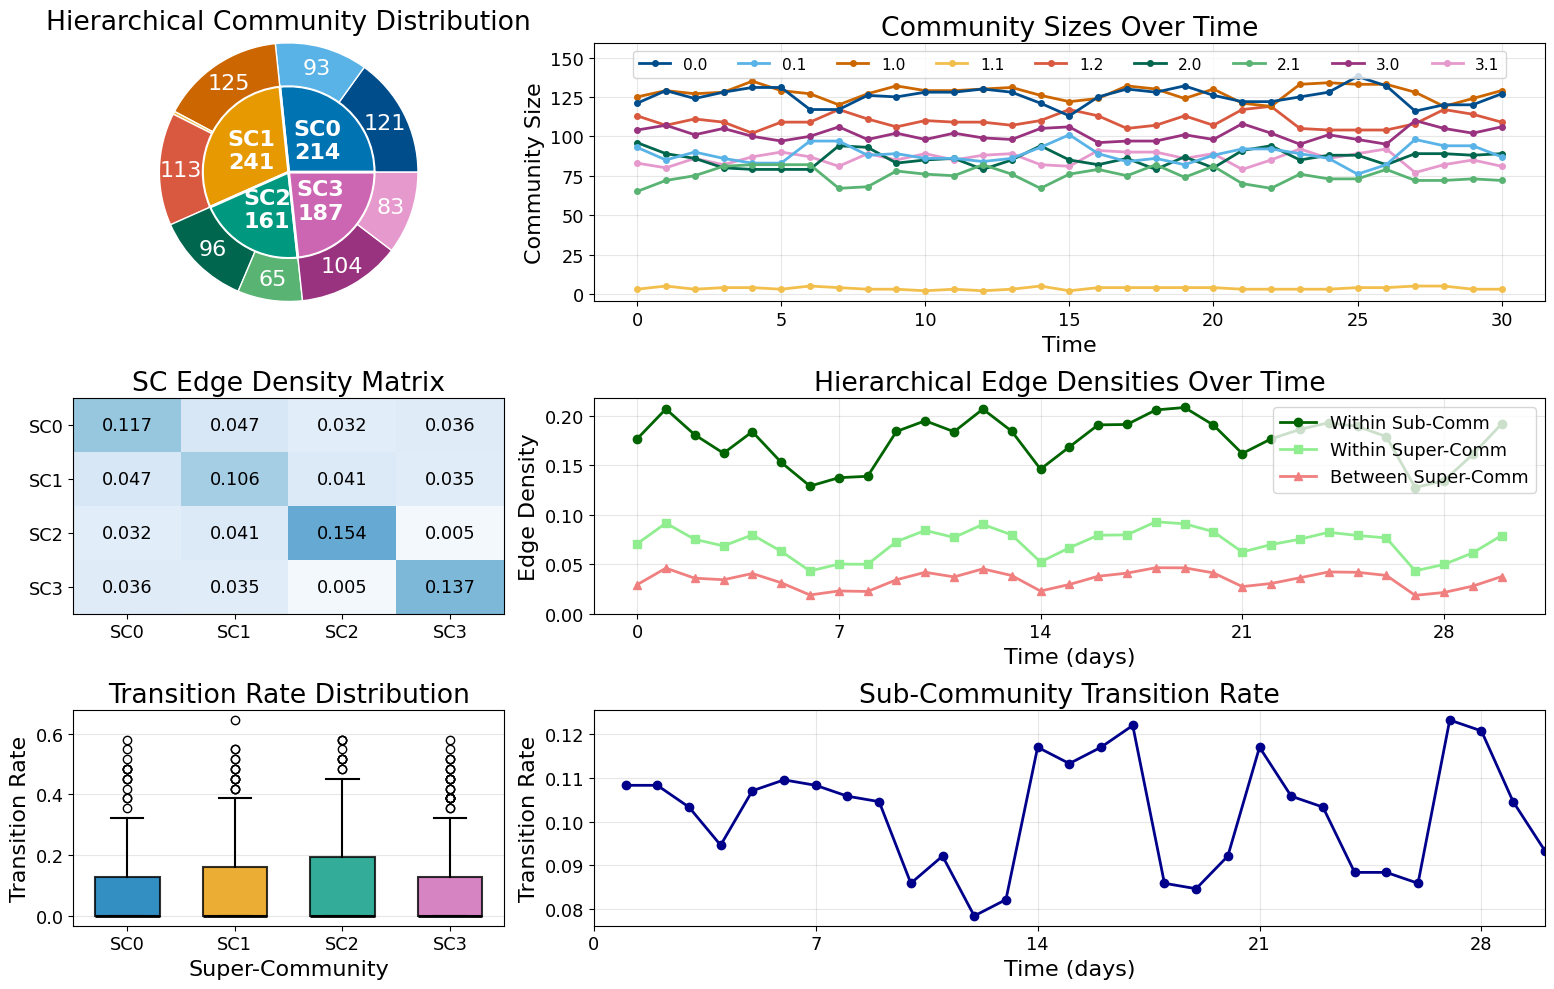

In [8]:
# load bike data output into hcs and plot 

am_pickle_name, result_pickle_name, dashboard_name = "output/am_bikes.pkl", "output/bike_results.pkl", "output/bike_dashboard"

adjacency_matrices = pickle.load(open(am_pickle_name, "rb"))

results = pickle.load(open(result_pickle_name, "rb"))

hcs = HierarchicalCommunityStructure.from_results(results)

latlon_df = pd.read_csv("data/node_list_extended.csv").sort_values("index")
lat_list = latlon_df['latitude'].values
lon_list = latlon_df['longitude'].values

f = plot_community_statistics_dashboard(hcs, adjacency_matrices, base_font_size=16, file_name=dashboard_name)
f.show()


Dashboard saved to: output/dashboard_simulated.pdf


C:\Users\jcreu\AppData\Local\Temp\ipykernel_22092\1381390310.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


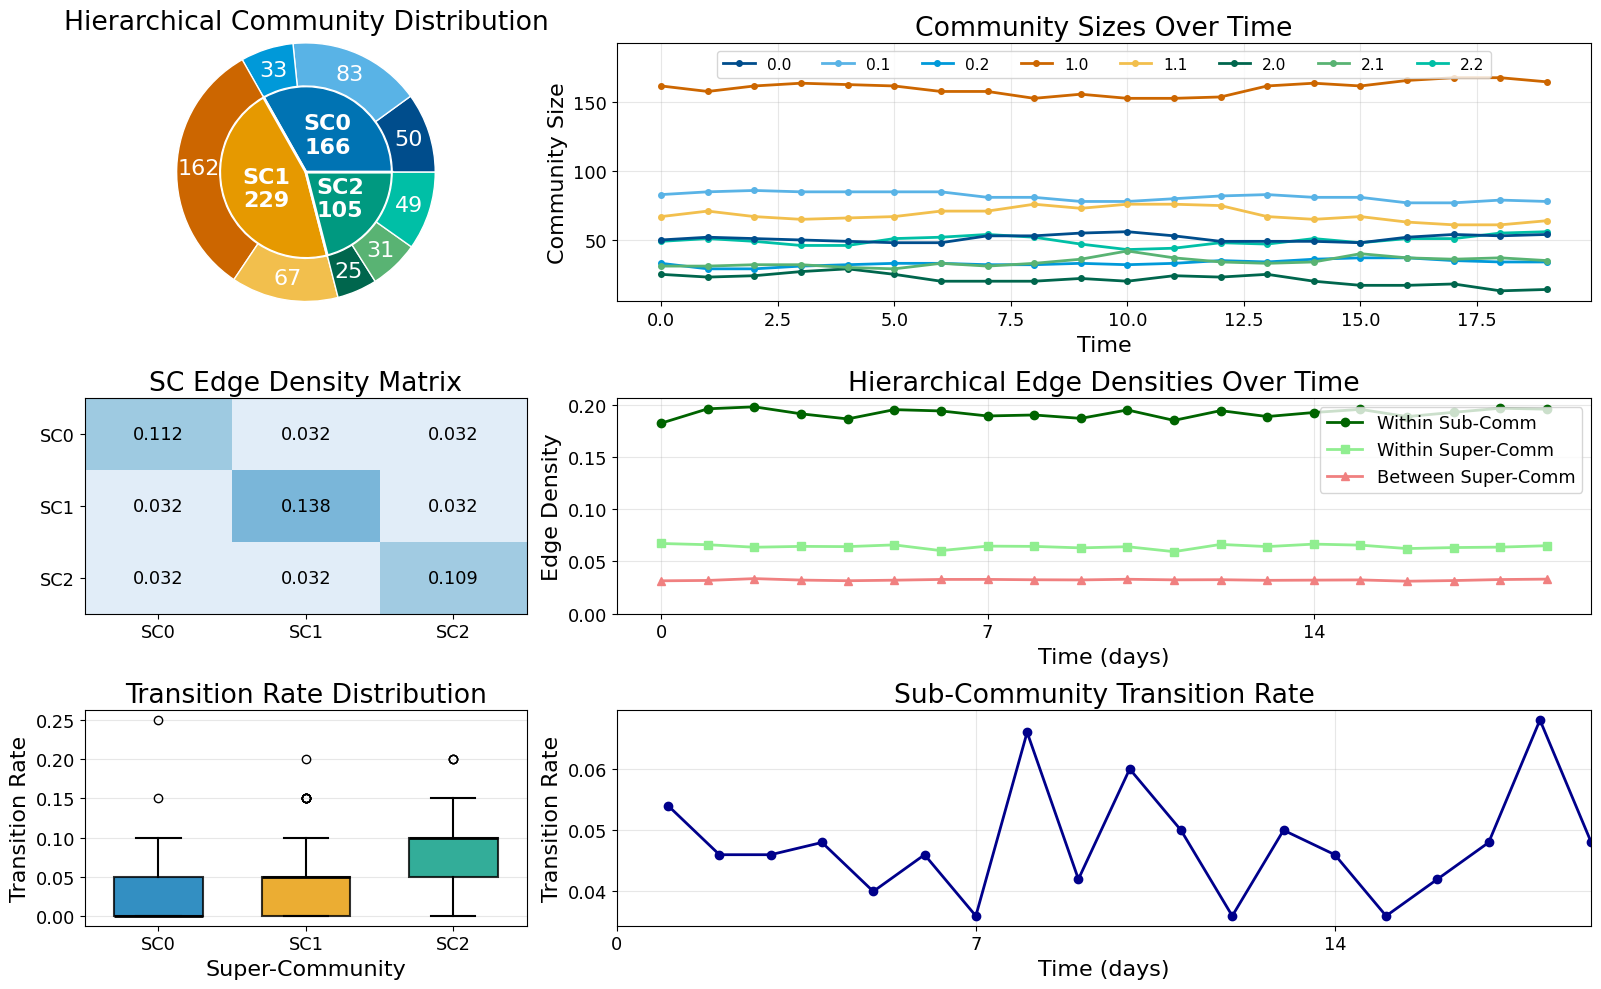

In [6]:
# simulate model and plot 
from dyn_hdcsbm import make_hierarchical_model

np.random.seed(4321)
model = make_hierarchical_model()

sim_adjacency_matrices = model.generate_adjacency_matrices()

sim_hcs = HierarchicalCommunityStructure.from_model(model)

dashboard_name_simulated = "output/dashboard_simulated"

f = plot_community_statistics_dashboard(sim_hcs, sim_adjacency_matrices, base_font_size=16, file_name=dashboard_name_simulated)

f.show() 


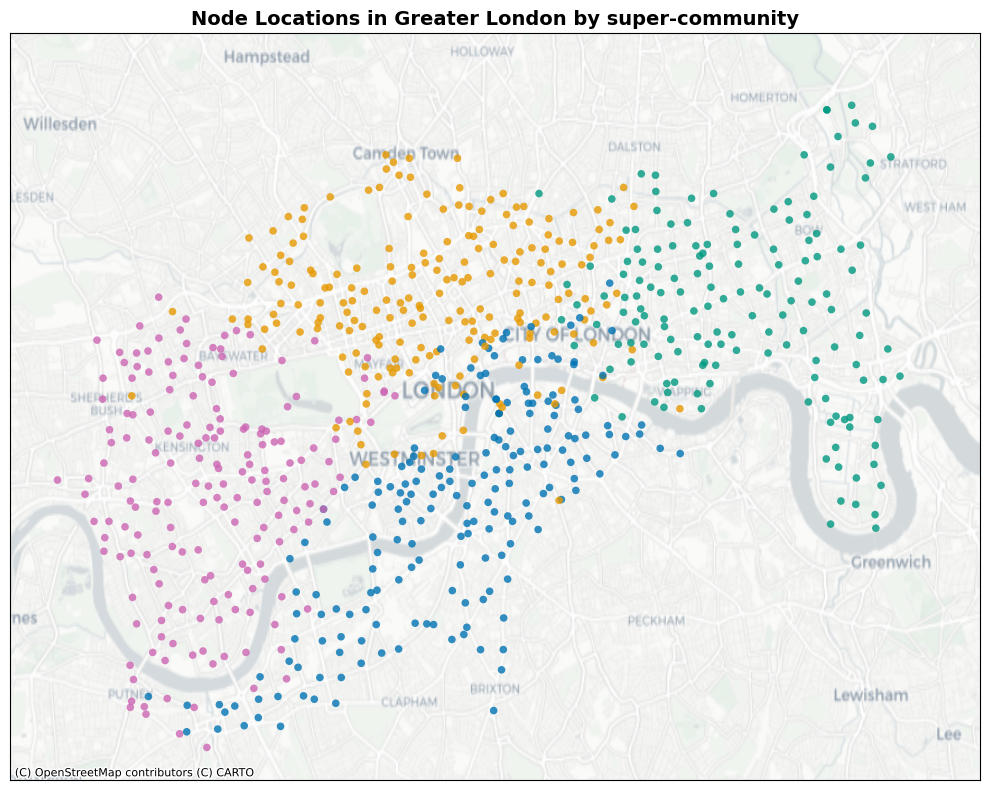

In [9]:
# PLot bike super communities on map 
import contextily as ctx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def bikes_lat_lon_super(hcs, lat_list, lon_list):
    """Scatter plot of bike sharing super communities with basemap for Greater London"""
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Extract super community coloring from hcs 
    super_community_id = hcs.super_communities

    valid_mask = ~(np.isnan(lat_list) | np.isnan(lon_list))
    valid_lats = lat_list[valid_mask]
    valid_lons = lon_list[valid_mask]
    valid_super_community_id = super_community_id[valid_mask]

    from plot_functions import generate_hierarchical_colors
    _, base_colors,_ = generate_hierarchical_colors()
    colors = [base_colors[sc] for sc in valid_super_community_id]
    
    # Plot the scatter points
    scatter = ax.scatter(valid_lons, valid_lats, c=colors, s=30, 
                        alpha=0.8, linewidth=0, edgecolor='black', zorder=5)
    
    # manual limits 
    ax.set_xlim(-0.25, 0.02)  
    ax.set_ylim(51.45, 51.56)
    
    # add a CC licensed base map 
    ctx.add_basemap(ax, crs='EPSG:4326', 
                    source=ctx.providers.CartoDB.Positron,
                    zoom=12)
    
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title('Node Locations in Greater London by super-community', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    return fig, ax

fig, _ = bikes_lat_lon_super(hcs, lat_list, lon_list)

fig.savefig("output/lat_lon_super_c_with_basemap.pdf", dpi=600, bbox_inches='tight')

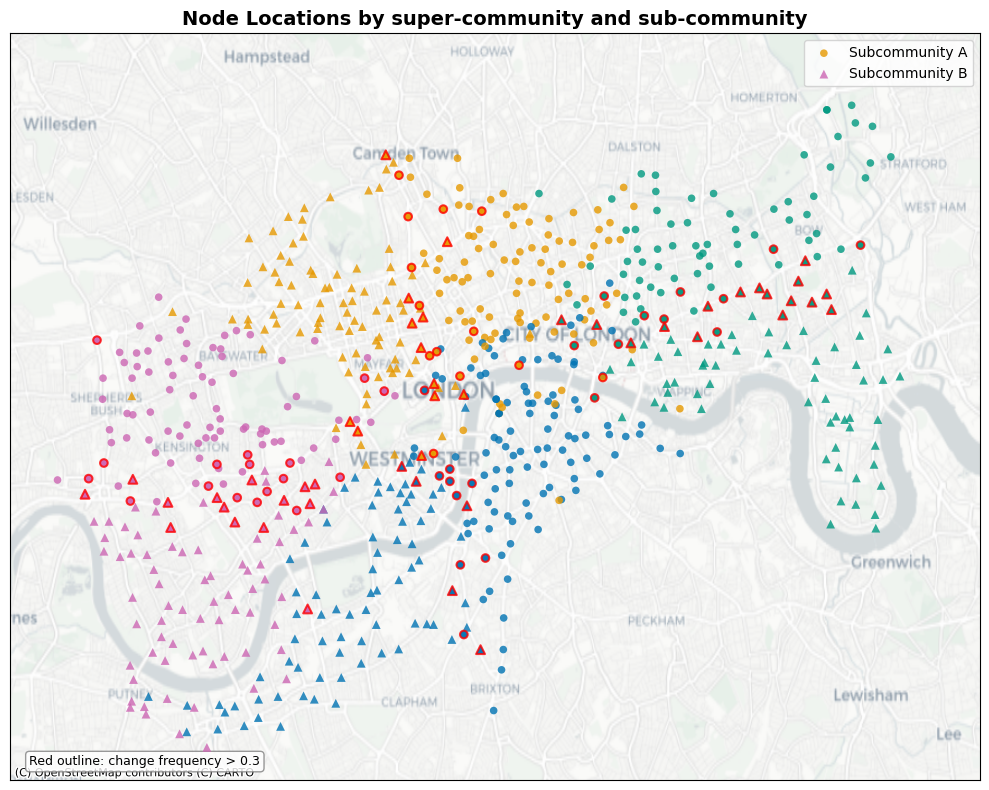

In [10]:
# extended plot with sub-communities and transition frequencies 

import contextily as ctx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

def calculate_subcommunity_stats(hcs, change_threshold=0.3):
    n_nodes = hcs.n_nodes
    T = hcs.n_timepoints
    
    predominant_sub = np.zeros(n_nodes, dtype=int)
    change_frequencies = np.zeros(n_nodes)

    # main assignment and change frequency     
    for i in range(n_nodes):
        node_subs = hcs.sub_communities[:, i]
        
        # mode
        mode_result = stats.mode(node_subs, keepdims=False)
        predominant_sub[i] = mode_result.mode
        
        # Change frequency
        changes = np.sum(node_subs[1:] != node_subs[:-1])
        change_frequencies[i] = changes / (T - 1)
    
    # Identify high-change nodes
    high_change_mask = change_frequencies > change_threshold
    
    return predominant_sub, change_frequencies, high_change_mask

def bike_lat_lon(hcs,lat_list, lon_list,  change_threshold=0.3):
    """Scatter plot with basemap for Greater London with subcommunity shapes and change indicators"""
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Calculate subcommunity statistics
    predominant_sub, change_frequencies, high_change_mask = calculate_subcommunity_stats(hcs, change_threshold)
    
    # Extract super community coloring from hcs 
    super_community_id = hcs.super_communities

    valid_mask = ~(np.isnan(lat_list) | np.isnan(lon_list))
    valid_lats = lat_list[valid_mask]
    valid_lons = lon_list[valid_mask]
    valid_super_community_id = super_community_id[valid_mask]
    valid_predominant_sub = predominant_sub[valid_mask]
    valid_high_change = high_change_mask[valid_mask]

    from plot_functions import generate_hierarchical_colors
    _, base_colors,_ = generate_hierarchical_colors()
    
    # Separate nodes by their predominant subcommunity (0 vs non-0)
    sub0_mask = valid_predominant_sub == 0
    non_sub0_mask = ~sub0_mask
    
    # Plot subcommunity 0 nodes (circles)
    if np.any(sub0_mask):
        colors_sub0 = [base_colors[sc] for sc in valid_super_community_id[sub0_mask]]
        ax.scatter(
            valid_lons[sub0_mask], valid_lats[sub0_mask], 
            c=colors_sub0, s=30, marker='o',
            alpha=0.8, edgecolor='black', linewidth=0,
            zorder=5, label='Subcommunity A'
        )
        
        # Add red outline for high-change nodes in subcommunity 0
        high_change_sub0 = valid_high_change[sub0_mask]
        if np.any(high_change_sub0):
            ax.scatter(
                valid_lons[sub0_mask][high_change_sub0], 
                valid_lats[sub0_mask][high_change_sub0],
                c=np.array(colors_sub0)[high_change_sub0], s=30, marker='o',
                alpha=0.8, edgecolor='red', linewidth=1.5,
                zorder=6
            )
    
    # Plot non-subcommunity 0 nodes (triangles)
    if np.any(non_sub0_mask):
        colors_non_sub0 = [base_colors[sc] for sc in valid_super_community_id[non_sub0_mask]]
        ax.scatter(
            valid_lons[non_sub0_mask], valid_lats[non_sub0_mask], 
            c=colors_non_sub0, s=40, marker='^',
            alpha=0.8, edgecolor='black', linewidth=0,
            zorder=5, label='Subcommunity B'
        )
        
        # Add red outline for high-change nodes in non-subcommunity 0
        high_change_non_sub0 = valid_high_change[non_sub0_mask]
        if np.any(high_change_non_sub0):
            ax.scatter(
                valid_lons[non_sub0_mask][high_change_non_sub0], 
                valid_lats[non_sub0_mask][high_change_non_sub0],
                c=np.array(colors_non_sub0)[high_change_non_sub0], s=40, marker='^',
                alpha=0.8, edgecolor='red', linewidth=1.5,
                zorder=6
            )
    
    # Set the extent
    ax.set_xlim(-0.25, 0.02)  
    ax.set_ylim(51.45, 51.56)
    
    # Add basemap
    ctx.add_basemap(ax, crs='EPSG:4326', 
                    source=ctx.providers.CartoDB.Positron,
                    zoom=12)
    
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title('Node Locations by super-community and sub-community', 
                 fontsize=14, fontweight='bold')
    
    # Add legend
    ax.legend(loc='upper right', fontsize=10)
    
    # Add text annotation for high-change indicator
    ax.text(0.02, 0.02, f'Red outline: change frequency > {change_threshold}', 
            transform=ax.transAxes, fontsize=9, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8))
    
    plt.tight_layout()
    return fig, ax

# Create the enhanced plot
fig, ax = bike_lat_lon(hcs, change_threshold=0.3, lat_list=lat_list, lon_list=lon_list)

fig.savefig("output/bs_latlon_sub.pdf", dpi=600, bbox_inches='tight')
